<a href="https://colab.research.google.com/github/Haidermushtaq/Computer-Vision-/blob/main/Lab002_Filtering_HAM10000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 02: Effect of Image Filtering on Skin-Lesion Classification

Haider Mushtaq (FA23-BAI-044)

Dataset: HAM10000. Models: best three from Lab 01. Six conditions per model (baseline + 5 spatial filters), identical split, preprocessing, training and evaluation across all 18 runs.



## 1. Configuration

In [3]:
import os, glob, time, copy, json, random, warnings
warnings.filterwarnings("ignore")

import cv2
cv2.setNumThreads(0)          # OpenCV threads + forked DataLoader workers deadlock on Colab
import numpy as np
import pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, balanced_accuracy_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# top three from Lab 01, Table 1 (test accuracy)
BEST_MODELS = ["ResNet50", "DenseNet121", "ResNet101"]

FILTERS = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]

MAX_PER_CLASS = 500      # subset cap; classes with fewer images are kept whole
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 10
LR            = 1e-4
NUM_WORKERS   = 2

ON_KAGGLE = os.path.isdir("/kaggle/input")
OUT = "/kaggle/working/lab02" if ON_KAGGLE else "/content/lab02"
for d in ["figures", "confusion", "curves", "reports"]:
    os.makedirs(f"{OUT}/{d}", exist_ok=True)

print(f"device={DEVICE}  models={BEST_MODELS}  epochs={EPOCHS}")

device=cuda  models=['ResNet50', 'DenseNet121', 'ResNet101']  epochs=10


## 2. Dataset preparation

In [4]:
# locate HAM10000: Kaggle input if attached, otherwise download via kagglehub (Colab: token in Secrets)
hits = glob.glob("/kaggle/input/**/HAM10000_metadata.csv", recursive=True) if ON_KAGGLE else []
if not hits:
    try:
        from google.colab import userdata
        os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
    except Exception:
        pass
    import kagglehub
    base = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    hits = glob.glob(f"{base}/**/HAM10000_metadata.csv", recursive=True)
assert hits, "HAM10000 not found. On Colab add a KAGGLE_API_TOKEN secret; on Kaggle attach the dataset."
meta_path = hits[0]
root = os.path.dirname(meta_path)
img_paths = {os.path.splitext(os.path.basename(p))[0]: p
             for p in glob.glob(f"{root}/**/*.jpg", recursive=True)}

meta = pd.read_csv(meta_path)
meta["path"] = meta["image_id"].map(img_paths)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

CLASS_NAMES = {
    "akiec": "Actinic keratoses", "bcc": "Basal cell carcinoma", "bkl": "Benign keratosis",
    "df": "Dermatofibroma", "mel": "Melanoma", "nv": "Melanocytic nevi", "vasc": "Vascular lesions",
}
CLASSES = sorted(meta["dx"].unique())
NUM_CLASSES = len(CLASSES)
cls2idx = {c: i for i, c in enumerate(CLASSES)}

print("Full HAM10000:", len(meta), "images")
print(meta["dx"].value_counts().to_string())

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Full HAM10000: 10015 images
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115


In [5]:
# subset: cap each class at MAX_PER_CLASS, sampled by lesion so duplicates of a lesion stay together
def cap_by_lesion(df, cap, seed=SEED):
    parts = []
    for cls, g in df.groupby("dx"):
        if len(g) <= cap:
            parts.append(g); continue
        lesions = g["lesion_id"].drop_duplicates().sample(frac=1, random_state=seed)
        keep, n = [], 0
        for lid in lesions:
            rows = g[g["lesion_id"] == lid]
            if n + len(rows) > cap: continue
            keep.append(rows); n += len(rows)
        parts.append(pd.concat(keep))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

sub = cap_by_lesion(meta, MAX_PER_CLASS)
sub["label"] = sub["dx"].map(cls2idx)

# group-aware stratified split: images of the same lesion never cross train/val/test
y, groups = sub["label"].values, sub["lesion_id"].values
outer = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
trval_idx, test_idx = next(outer.split(sub, y, groups))
inner = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
tr_rel, va_rel = next(inner.split(sub.iloc[trval_idx], y[trval_idx], groups[trval_idx]))
train_idx, val_idx = trval_idx[tr_rel], trval_idx[va_rel]

splits = {"train": sub.iloc[train_idx], "val": sub.iloc[val_idx], "test": sub.iloc[test_idx]}
dist = pd.DataFrame({k: v["dx"].value_counts() for k, v in splits.items()}).fillna(0).astype(int)
dist["total"] = dist.sum(1)
print(f"Subset: {len(sub)} images  |  train {len(train_idx)}  val {len(val_idx)}  test {len(test_idx)}\n")
print(dist.to_string())
dist.to_csv(f"{OUT}/class_distribution.csv")

counts = np.bincount(splits["train"]["label"], minlength=NUM_CLASSES)
class_weights = torch.tensor(counts.sum() / (NUM_CLASSES * counts), dtype=torch.float32).to(DEVICE)

Subset: 2584 images  |  train 1813  val 390  test 381

       train  val  test  total
dx                            
akiec    225   51    51    327
bcc      333   81    86    500
bkl      351   81    68    500
df        75   18    22    115
mel      365   72    63    500
nv       368   70    62    500
vasc      96   17    29    142


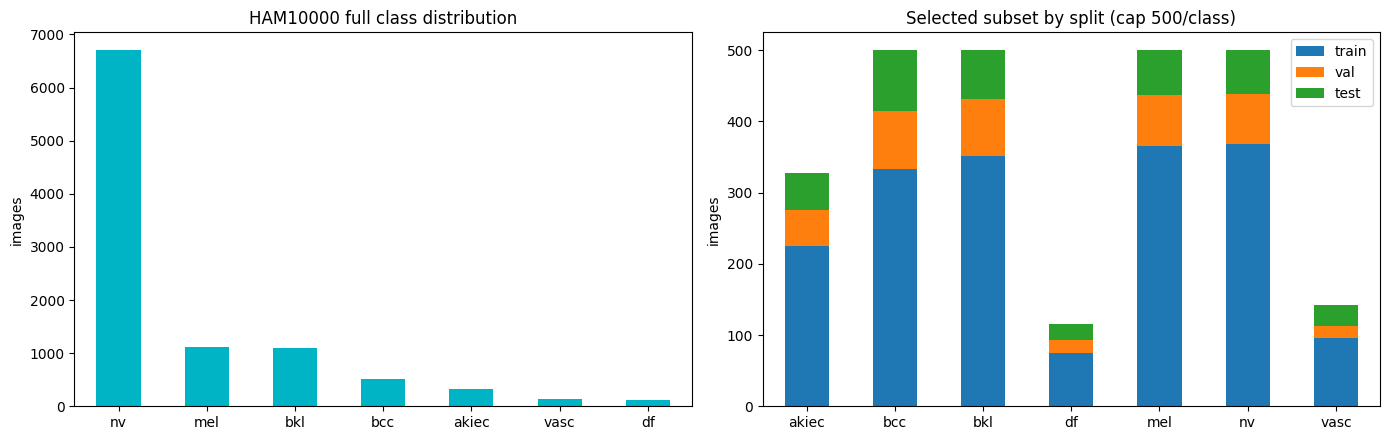

In [6]:
# class distribution figure
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
meta["dx"].value_counts().plot.bar(ax=ax[0], color="#00B4C5")
ax[0].set_title("HAM10000 full class distribution"); ax[0].set_xlabel(""); ax[0].set_ylabel("images")
dist.drop(columns="total").plot.bar(ax=ax[1], stacked=True)
ax[1].set_title(f"Selected subset by split (cap {MAX_PER_CLASS}/class)"); ax[1].set_xlabel(""); ax[1].set_ylabel("images")
for a in ax: a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(f"{OUT}/figures/class_distribution.png", dpi=150); plt.show()

## 3. Image filtering

In [7]:
SHARPEN_KERNEL = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)

def apply_filter(img_rgb: np.ndarray, name: str) -> np.ndarray:
    """img_rgb: uint8 HxWx3. Returns uint8 HxWx3."""
    if name == "No Filter":
        return img_rgb
    if name == "Average":
        return cv2.blur(img_rgb, (5, 5))
    if name == "Gaussian":
        return cv2.GaussianBlur(img_rgb, (5, 5), sigmaX=1.5)
    if name == "Median":
        return cv2.medianBlur(img_rgb, 5)
    if name == "Sharpening":
        return cv2.filter2D(img_rgb, -1, SHARPEN_KERNEL)
    if name == "Sobel":
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
        mag = cv2.magnitude(gx, gy)
        mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)   # 3 channels so pretrained stems still fit
    raise ValueError(name)


class FilterTransform:
    """PIL -> PIL. Applied after resize so kernel size means the same thing for every image."""
    def __init__(self, name): self.name = name
    def __call__(self, img):
        return Image.fromarray(apply_filter(np.asarray(img), self.name))


MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def build_transforms(filter_name):
    common = [transforms.Resize((IMG_SIZE, IMG_SIZE)), FilterTransform(filter_name)]
    train_tf = transforms.Compose(common + [
        transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20), transforms.ColorJitter(0.15, 0.15, 0.15),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD),
    ])
    eval_tf = transforms.Compose(common + [transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    return train_tf, eval_tf

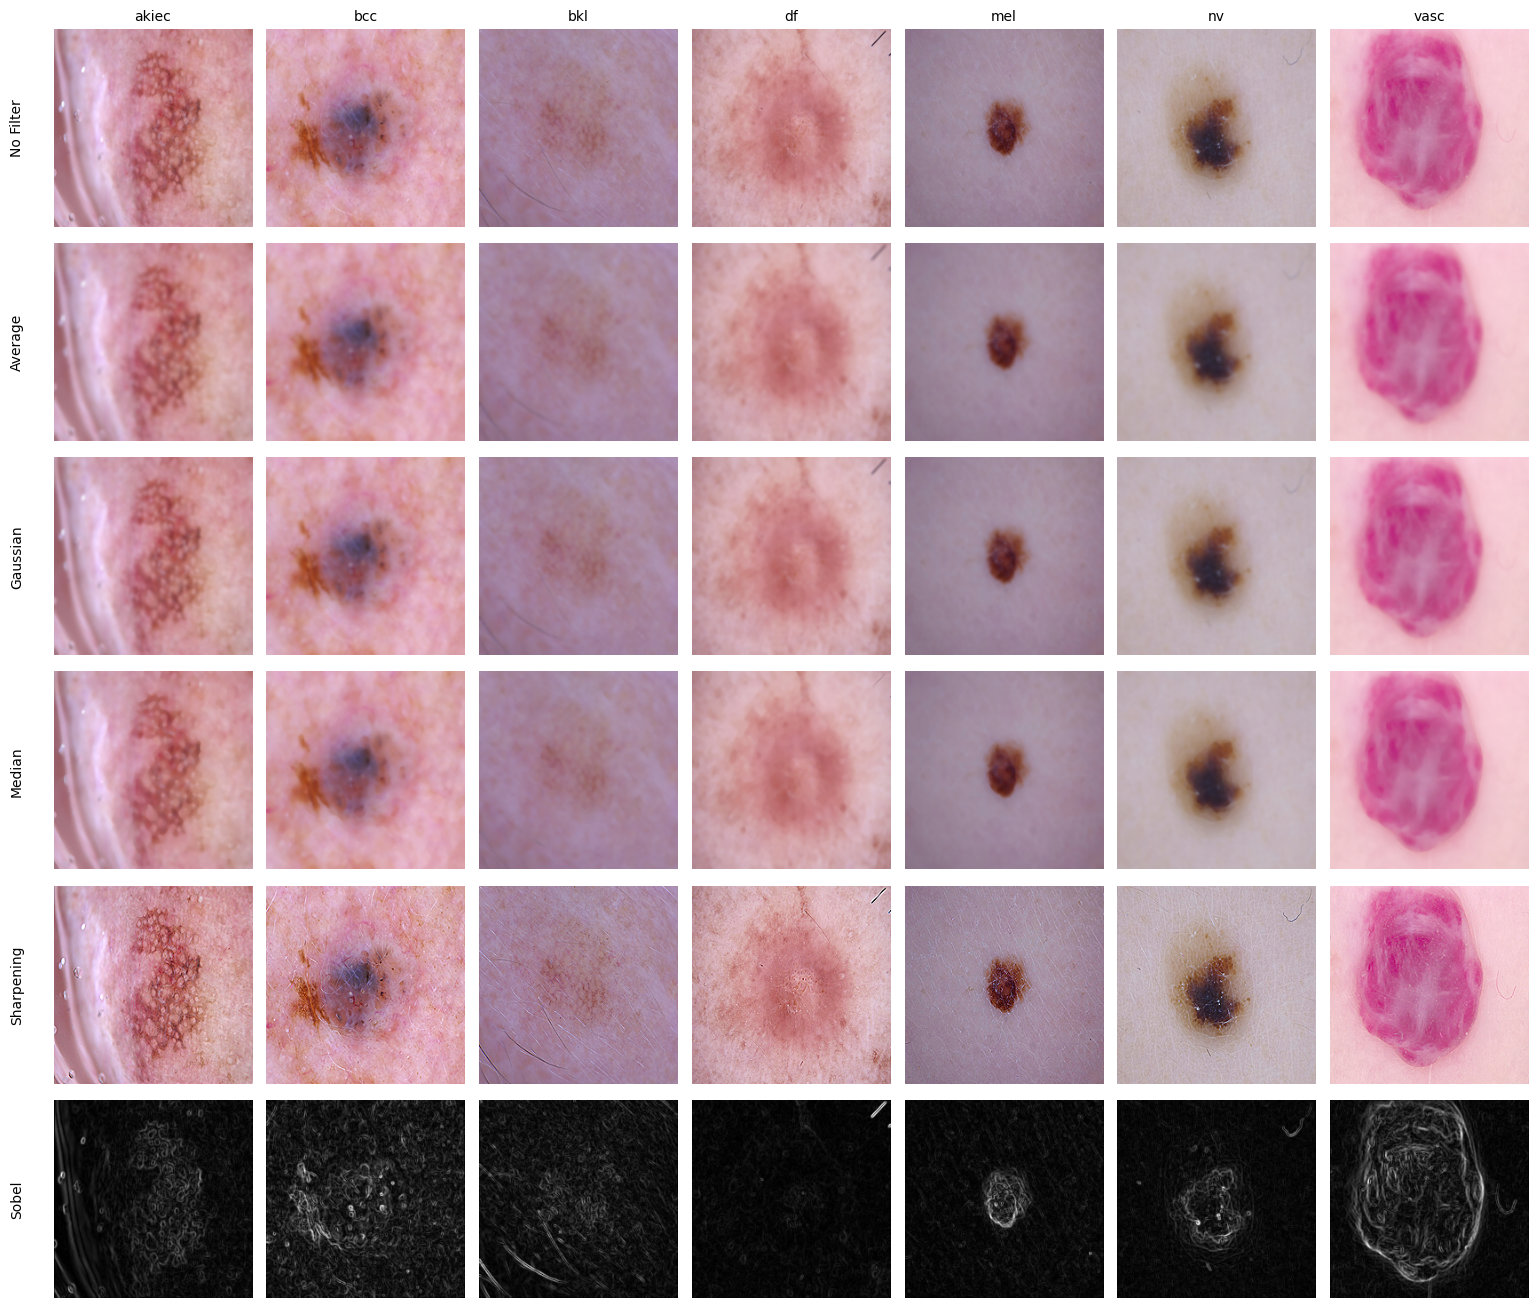

In [8]:
# filtered image examples: one image per class, one row per filter
sample = splits["train"].groupby("dx").head(1).sort_values("dx")
fig, axes = plt.subplots(len(FILTERS), NUM_CLASSES, figsize=(2.2 * NUM_CLASSES, 2.2 * len(FILTERS)))
for r, f in enumerate(FILTERS):
    for c, (_, row) in enumerate(sample.iterrows()):
        img = np.asarray(Image.open(row["path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
        axes[r, c].imshow(apply_filter(img, f)); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(row["dx"], fontsize=10)
        if c == 0: axes[r, c].text(-0.15, 0.5, f, transform=axes[r, c].transAxes,
                                   rotation=90, va="center", ha="right", fontsize=10)
plt.tight_layout(); plt.savefig(f"{OUT}/figures/filter_examples.png", dpi=150); plt.show()

In [9]:
class LesionDataset(Dataset):
    def __init__(self, df, tf):
        self.paths, self.labels, self.tf = df["path"].tolist(), df["label"].tolist(), tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB")), self.labels[i]

def build_loaders(filter_name):
    train_tf, eval_tf = build_transforms(filter_name)
    mk = lambda df, tf, sh: DataLoader(LesionDataset(df, tf), batch_size=BATCH_SIZE, shuffle=sh,
                                       num_workers=NUM_WORKERS, pin_memory=True)
    return (mk(splits["train"], train_tf, True),
            mk(splits["val"],   eval_tf,  False),
            mk(splits["test"],  eval_tf,  False))

## 4. Model loading

In [10]:
def build_model(name, n=NUM_CLASSES):
    w = "IMAGENET1K_V1"
    if name == "AlexNet":          m = models.alexnet(weights=w);         m.classifier[6] = nn.Linear(4096, n)
    elif name == "VGG16":          m = models.vgg16(weights=w);           m.classifier[6] = nn.Linear(4096, n)
    elif name == "VGG19":          m = models.vgg19(weights=w);           m.classifier[6] = nn.Linear(4096, n)
    elif name == "ResNet18":       m = models.resnet18(weights=w);        m.fc = nn.Linear(m.fc.in_features, n)
    elif name == "ResNet50":       m = models.resnet50(weights=w);        m.fc = nn.Linear(m.fc.in_features, n)
    elif name == "ResNet101":      m = models.resnet101(weights=w);       m.fc = nn.Linear(m.fc.in_features, n)
    elif name == "DenseNet121":    m = models.densenet121(weights=w);     m.classifier = nn.Linear(m.classifier.in_features, n)
    elif name == "EfficientNet-B0":m = models.efficientnet_b0(weights=w); m.classifier[1] = nn.Linear(m.classifier[1].in_features, n)
    else: raise ValueError(name)
    return m.to(DEVICE)

for name in BEST_MODELS:      # warm the weight cache once
    build_model(name); torch.cuda.empty_cache()
print("weights cached")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 116MB/s]


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 176MB/s]


weights cached


## 5. Training and evaluation

In [11]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    train = optimizer is not None
    model.train(train)
    tot_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
                out = model(x); loss = criterion(out, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            tot_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item(); n += y.size(0)
    return tot_loss / n, correct / n


@torch.no_grad()
def predict(model, loader):
    model.eval(); ys, probs = [], []
    for x, y in loader:
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            out = model(x.to(DEVICE, non_blocking=True))
        probs.append(torch.softmax(out.float(), 1).cpu().numpy()); ys.append(y.numpy())
    y_true, y_prob = np.concatenate(ys), np.concatenate(probs)
    return y_true, y_prob.argmax(1), y_prob


def metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy":          accuracy_score(y_true, y_pred) * 100,
        "Precision":         precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Recall":            recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "F1-score":          f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        "Macro-F1":          f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred) * 100,
        "AUC":               roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro") * 100,
    }


def train_and_evaluate(model_name, filter_name):
    train_loader, val_loader, test_loader = build_loaders(filter_name)
    model = build_model(model_name)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc"]}
    best_acc, best_state = -1, None
    for ep in range(EPOCHS):
        print(f"    ep{ep+1:02d} ...", end="\n", flush=True)
        tl, ta = run_epoch(model, train_loader, criterion, optimizer, scaler)
        vl, va = run_epoch(model, val_loader, criterion)
        scheduler.step()
        for k, v in zip(hist, (tl, ta, vl, va)): hist[k].append(v)
        if va > best_acc: best_acc, best_state = va, copy.deepcopy(model.state_dict())
        print(f"    ep{ep+1:02d} loss {tl:.3f}/{vl:.3f}  acc {ta*100:.1f}/{va*100:.1f}")

    model.load_state_dict(best_state)
    y_true, y_pred, y_prob = predict(model, test_loader)
    del model; torch.cuda.empty_cache()
    return metrics(y_true, y_pred, y_prob), hist, (y_true, y_pred)

## 6. Experiments: baseline + filters, all three models

In [12]:
RESULTS_CSV = f"{OUT}/results.csv"
results = pd.read_csv(RESULTS_CSV) if os.path.exists(RESULTS_CSV) else pd.DataFrame()
done = set(zip(results.get("Model", []), results.get("Filter", [])))

per_class_rows, histories, cms = [], {}, {}

for model_name in BEST_MODELS:
    for filter_name in FILTERS:
        key = (model_name, filter_name)
        if key in done:
            print(f"skip {key} (already in results.csv)"); continue
        print(f"\n== {model_name} | {filter_name} ==")
        t0 = time.time()
        m, hist, (y_true, y_pred) = train_and_evaluate(model_name, filter_name)

        row = {"Model": model_name, "Filter": filter_name, **m, "Train time (min)": (time.time() - t0) / 60}
        results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)
        results.to_csv(RESULTS_CSV, index=False)                      # checkpoint after every run

        histories[key] = hist; cms[key] = confusion_matrix(y_true, y_pred)
        json.dump(hist, open(f"{OUT}/curves/{model_name}_{filter_name}.json", "w"))
        np.save(f"{OUT}/confusion/{model_name}_{filter_name}.npy", cms[key])

        rep = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
        for c in CLASSES:
            per_class_rows.append({"Model": model_name, "Filter": filter_name, "Class": c,
                                   "Precision": rep[c]["precision"] * 100, "Recall": rep[c]["recall"] * 100,
                                   "F1": rep[c]["f1-score"] * 100, "Support": rep[c]["support"]})
        pd.DataFrame(per_class_rows).to_csv(f"{OUT}/reports/per_class.csv", index=False)

        print(f"   -> acc {m['Accuracy']:.2f}  macroF1 {m['Macro-F1']:.2f}  balAcc {m['Balanced Accuracy']:.2f}  "
              f"AUC {m['AUC']:.2f}  ({row['Train time (min)']:.1f} min)")

results = results.set_index(["Model", "Filter"]).loc[[(m, f) for m in BEST_MODELS for f in FILTERS]].reset_index()
results.to_csv(RESULTS_CSV, index=False)


== ResNet50 | No Filter ==
    ep01 ...
    ep01 loss 1.501/1.357  acc 50.0/64.6
    ep02 ...
    ep02 loss 1.185/1.176  acc 67.8/65.9
    ep03 ...
    ep03 loss 1.031/1.243  acc 75.7/66.9
    ep04 ...
    ep04 loss 0.935/1.269  acc 81.5/67.2
    ep05 ...
    ep05 loss 0.870/1.295  acc 85.6/69.7
    ep06 ...
    ep06 loss 0.817/1.181  acc 88.6/67.7
    ep07 ...
    ep07 loss 0.769/1.199  acc 92.2/73.1
    ep08 ...
    ep08 loss 0.735/1.146  acc 93.9/72.6
    ep09 ...
    ep09 loss 0.722/1.155  acc 95.0/73.1
    ep10 ...
    ep10 loss 0.704/1.165  acc 96.2/72.6
   -> acc 75.33  macroF1 76.41  balAcc 76.30  AUC 94.88  (4.2 min)

== ResNet50 | Average ==
    ep01 ...
    ep01 loss 1.552/1.294  acc 49.6/61.8
    ep02 ...
    ep02 loss 1.223/1.268  acc 65.0/61.8
    ep03 ...
    ep03 loss 1.118/1.263  acc 71.0/64.4
    ep04 ...
    ep04 loss 1.006/1.288  acc 76.6/65.4
    ep05 ...
    ep05 loss 0.929/1.276  acc 81.8/64.4
    ep06 ...
    ep06 loss 0.867/1.260  acc 85.7/66.9
    ep07 ...
  

## 7. Results table

In [13]:
cols = ["Model", "Filter", "Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "Balanced Accuracy", "AUC"]
table = results[cols].round(2)
print(table.to_string(index=False))
table.to_csv(f"{OUT}/comparison_table.csv", index=False)

      Model     Filter  Accuracy  Precision  Recall  F1-score  Macro-F1  Balanced Accuracy   AUC
   ResNet50  No Filter     75.33      77.87   76.30     74.47     76.41              76.30 94.88
   ResNet50    Average     75.59      76.73   77.98     75.85     76.71              77.98 94.76
   ResNet50   Gaussian     76.90      78.27   77.75     76.78     77.90              77.75 95.63
   ResNet50     Median     71.92      73.22   74.30     71.69     72.78              74.30 94.03
   ResNet50 Sharpening     74.54      74.99   76.75     74.36     75.44              76.75 94.91
   ResNet50      Sobel     55.12      54.05   56.60     54.62     54.46              56.60 86.41
DenseNet121  No Filter     74.80      75.22   77.20     74.56     75.89              77.20 95.07
DenseNet121    Average     72.70      72.41   74.39     72.57     72.87              74.39 94.72
DenseNet121   Gaussian     71.65      72.17   75.06     71.11     73.08              75.06 94.90
DenseNet121     Median     73.

## 8. Visualization

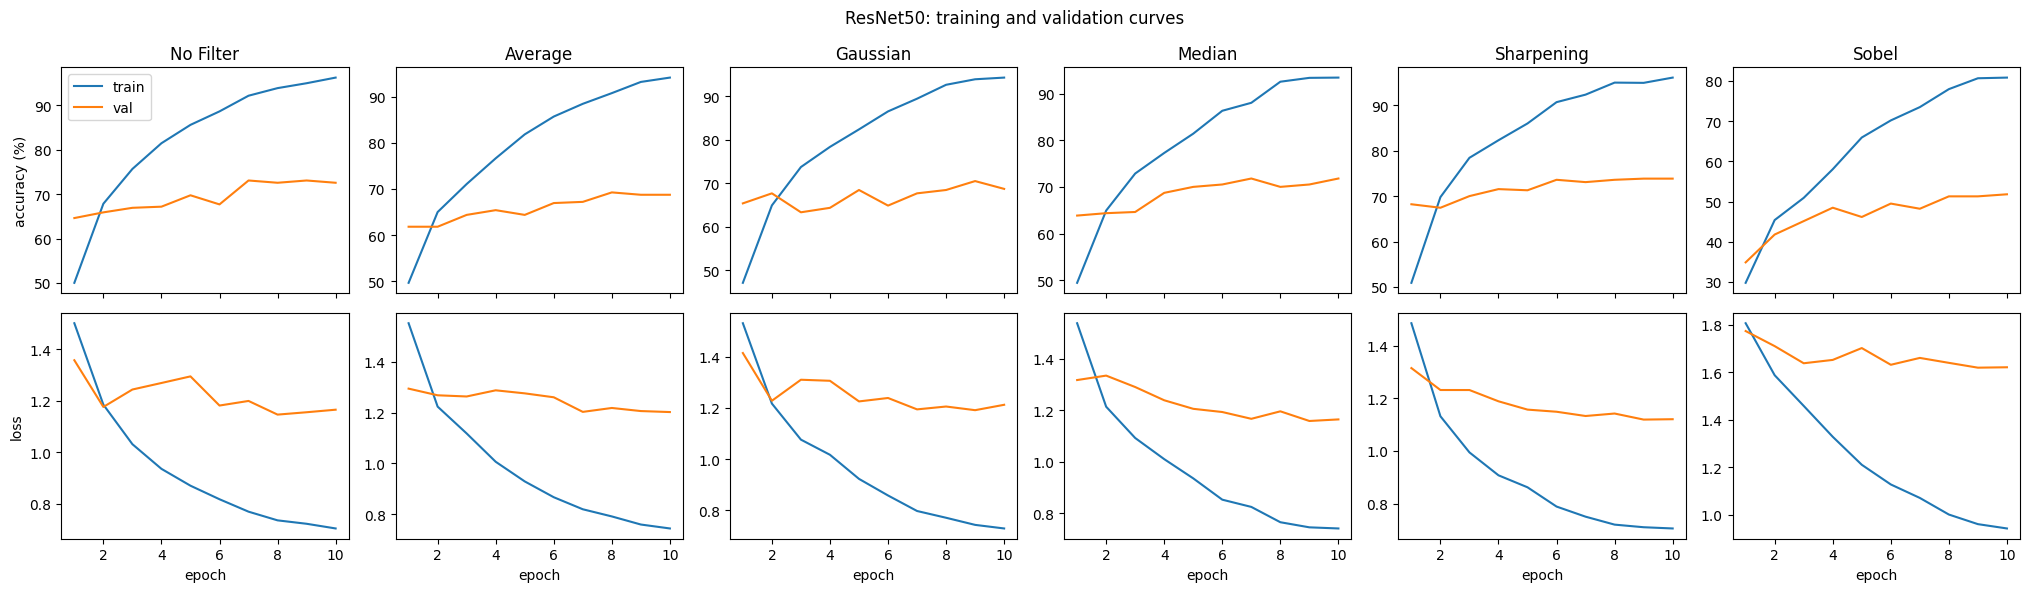

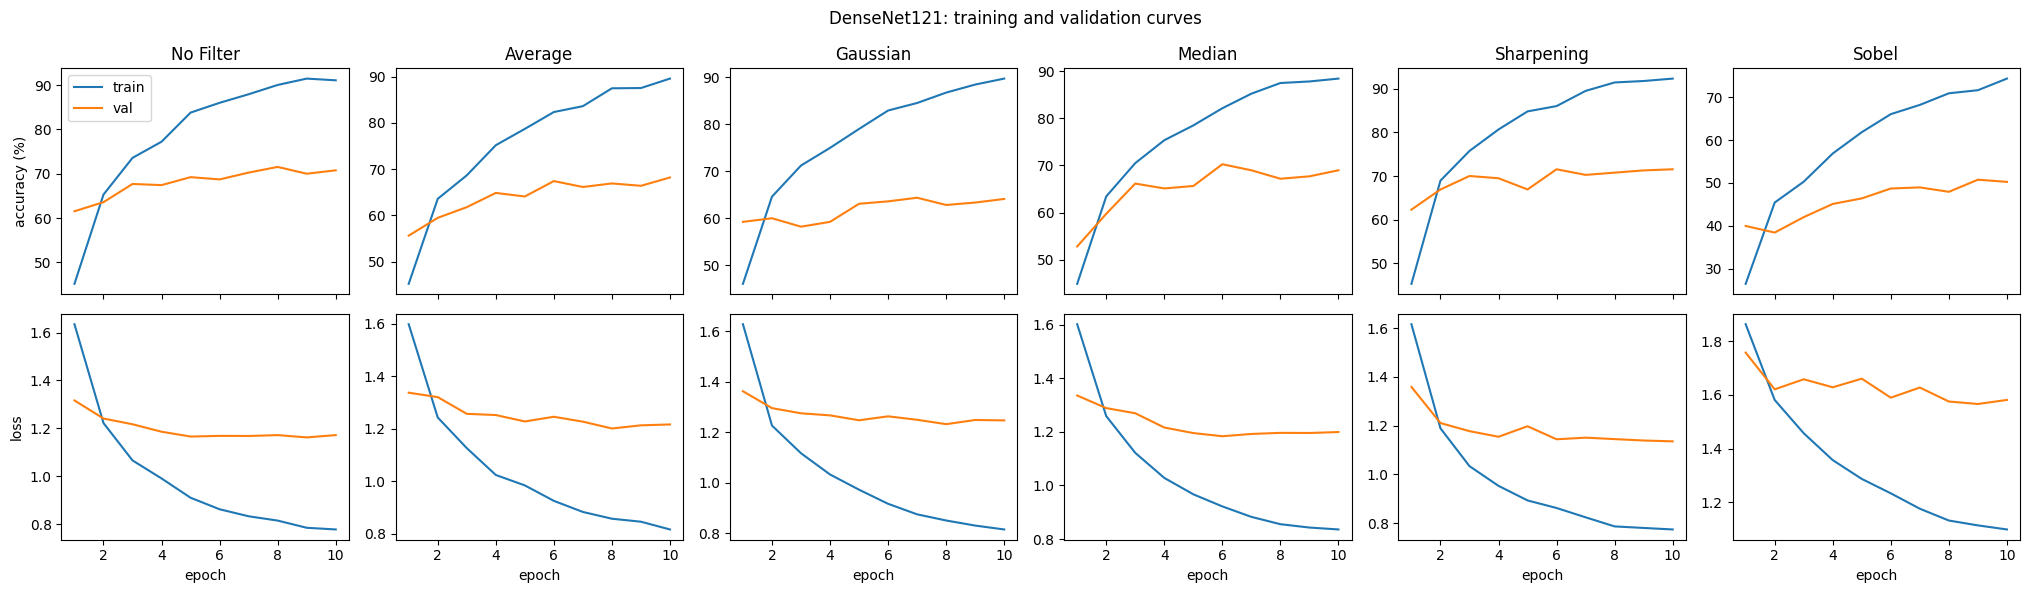

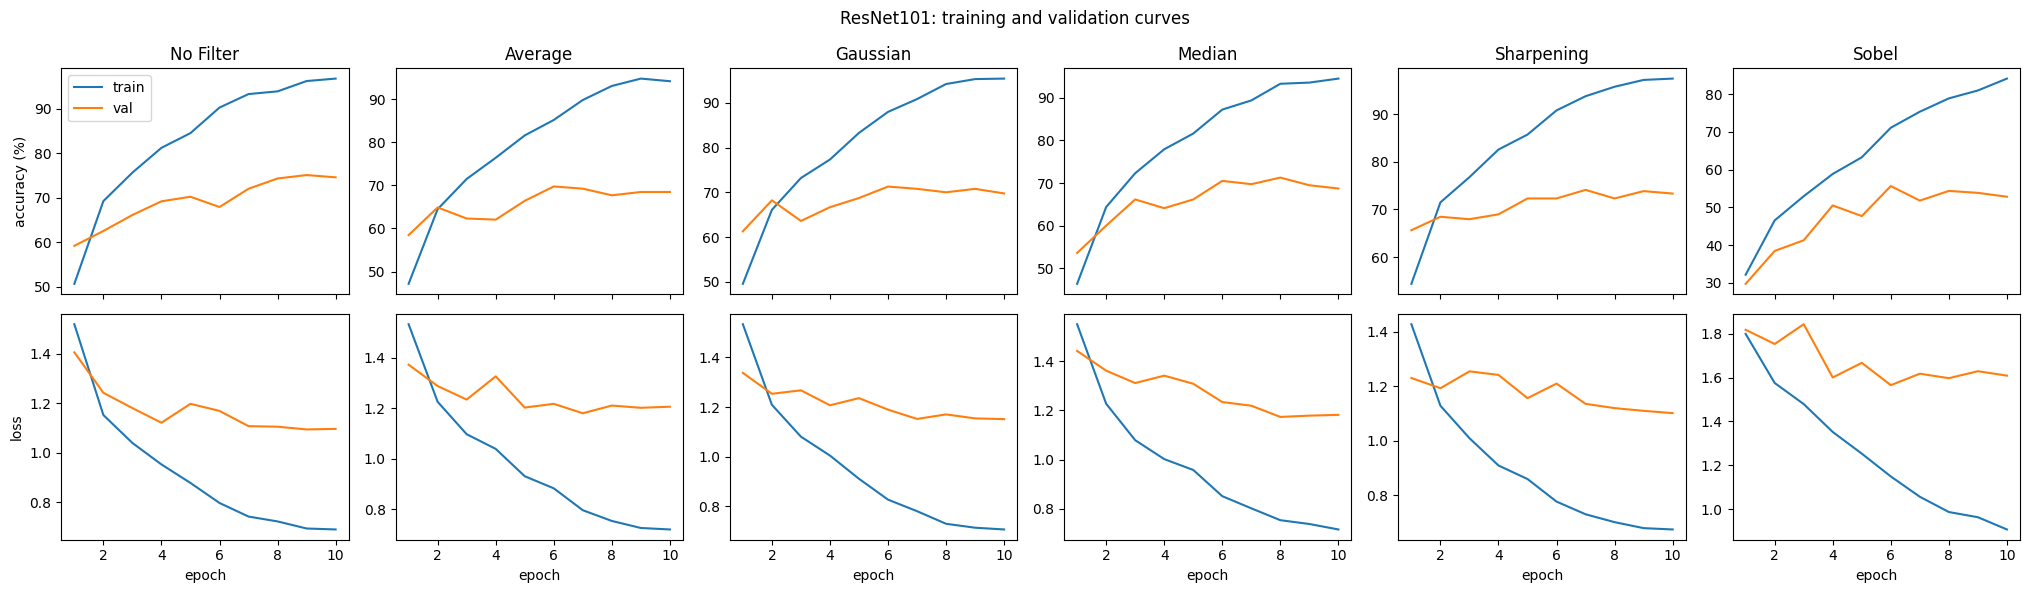

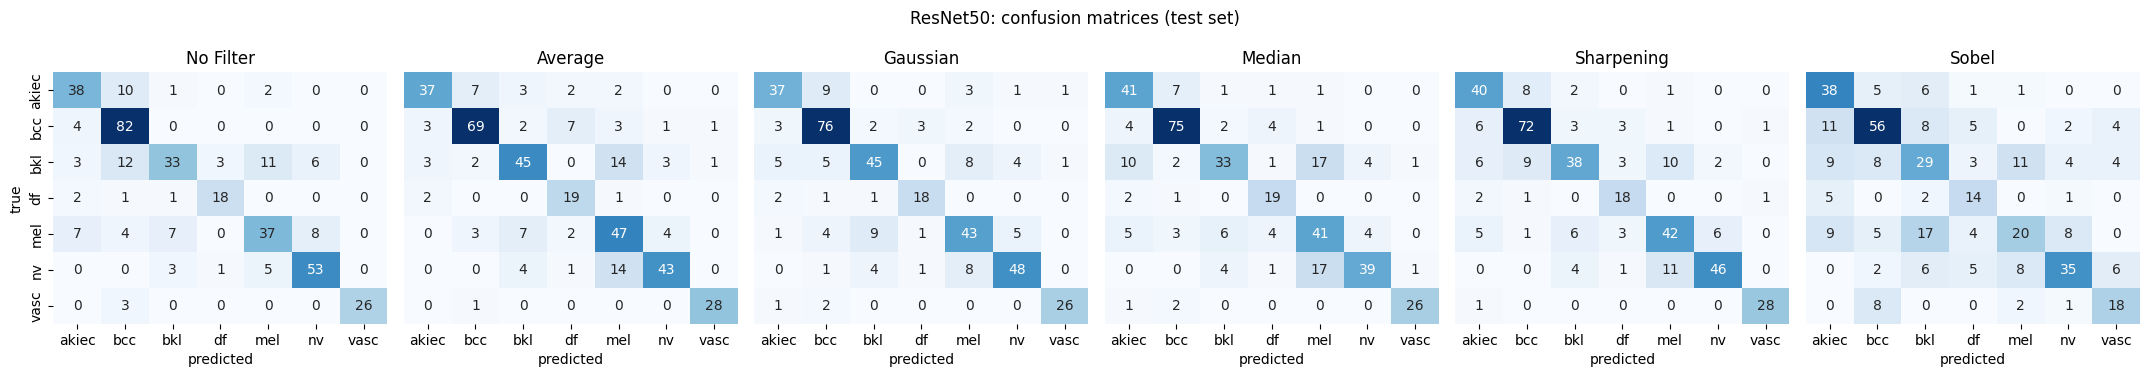

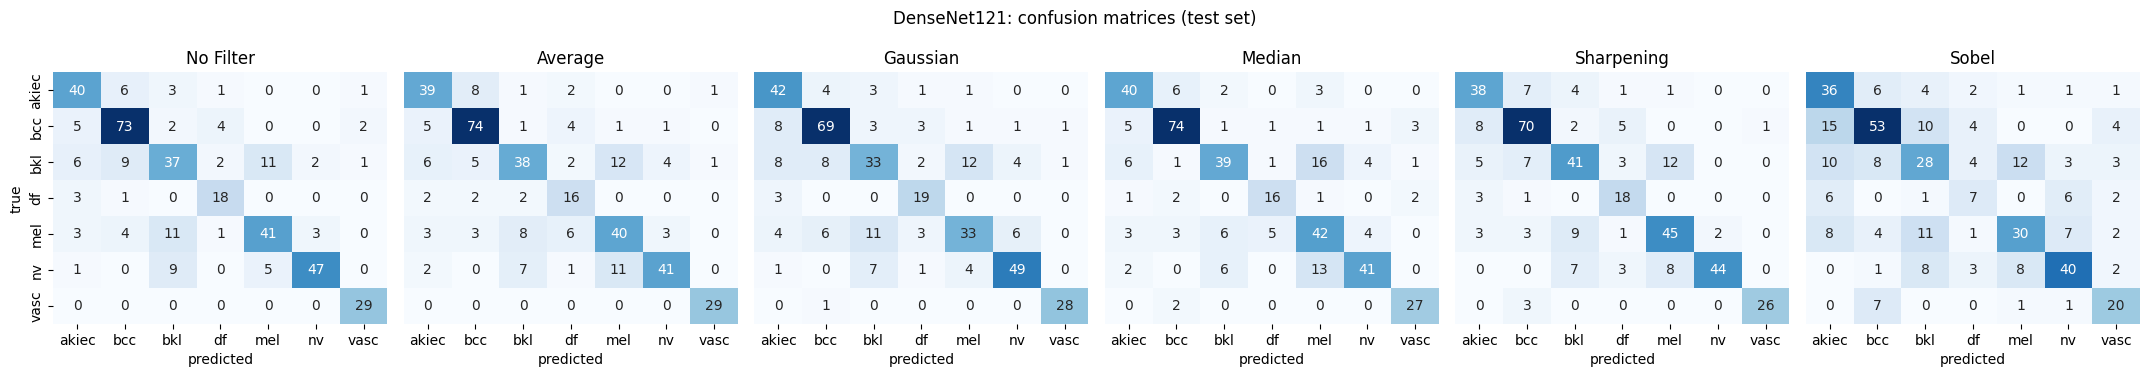

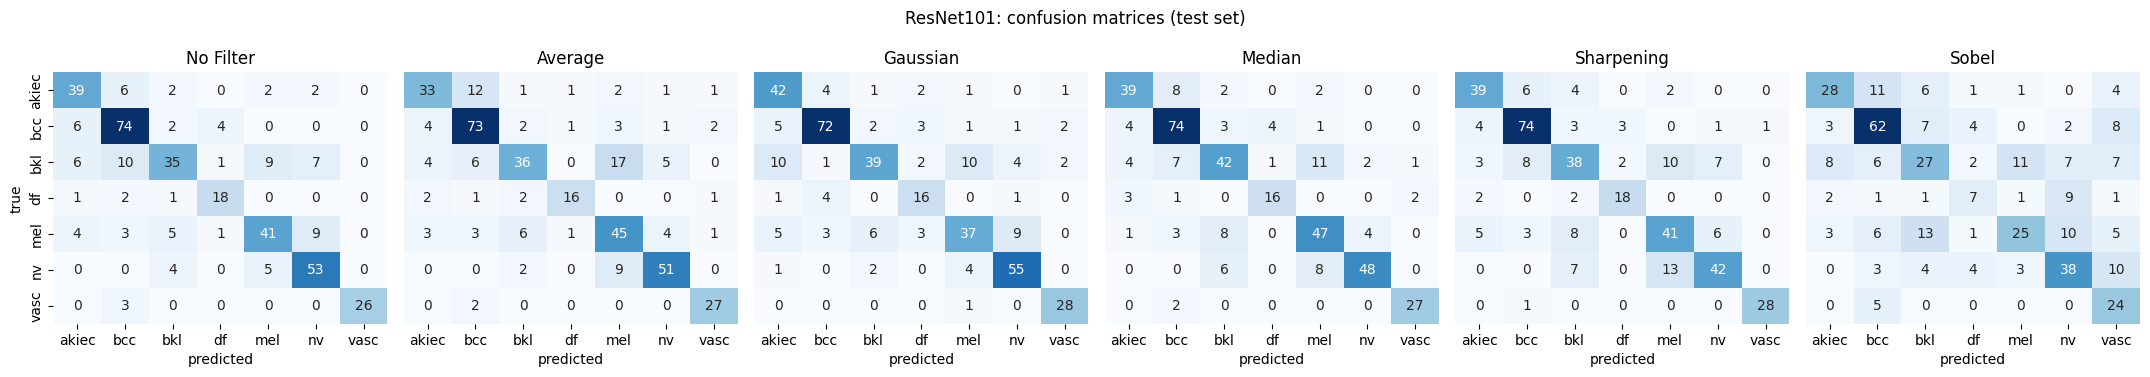

In [14]:
# reload artefacts from disk in case the kernel restarted mid-way
for model_name in BEST_MODELS:
    for filter_name in FILTERS:
        key = (model_name, filter_name)
        if key not in histories:
            histories[key] = json.load(open(f"{OUT}/curves/{model_name}_{filter_name}.json"))
        if key not in cms:
            cms[key] = np.load(f"{OUT}/confusion/{model_name}_{filter_name}.npy")

# training / validation curves: one figure per model, one column per filter
for model_name in BEST_MODELS:
    fig, axes = plt.subplots(2, len(FILTERS), figsize=(3.4 * len(FILTERS), 6), sharex=True)
    for c, filter_name in enumerate(FILTERS):
        h = histories[(model_name, filter_name)]; ep = range(1, EPOCHS + 1)
        axes[0, c].plot(ep, np.array(h["train_acc"]) * 100, label="train"); axes[0, c].plot(ep, np.array(h["val_acc"]) * 100, label="val")
        axes[1, c].plot(ep, h["train_loss"], label="train");                axes[1, c].plot(ep, h["val_loss"], label="val")
        axes[0, c].set_title(filter_name); axes[1, c].set_xlabel("epoch")
    axes[0, 0].set_ylabel("accuracy (%)"); axes[1, 0].set_ylabel("loss"); axes[0, 0].legend()
    fig.suptitle(f"{model_name}: training and validation curves"); plt.tight_layout()
    plt.savefig(f"{OUT}/figures/curves_{model_name}.png", dpi=150); plt.show()

# confusion matrices: same layout
for model_name in BEST_MODELS:
    fig, axes = plt.subplots(1, len(FILTERS), figsize=(3.6 * len(FILTERS), 3.8))
    for c, filter_name in enumerate(FILTERS):
        sns.heatmap(cms[(model_name, filter_name)], annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=CLASSES, yticklabels=CLASSES if c == 0 else False, ax=axes[c])
        axes[c].set_title(filter_name); axes[c].set_xlabel("predicted")
    axes[0].set_ylabel("true"); fig.suptitle(f"{model_name}: confusion matrices (test set)"); plt.tight_layout()
    plt.savefig(f"{OUT}/figures/confusion_{model_name}.png", dpi=150); plt.show()

## 9. Comparative analysis

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define variables that might have been lost in a kernel restart or not explicitly in this cell
ON_KAGGLE = os.path.isdir("/kaggle/input")
OUT = "/kaggle/working/lab02" if ON_KAGGLE else "/content/lab02"
BEST_MODELS = ["ResNet50", "DenseNet121", "ResNet101"]
FILTERS = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]

RESULTS_CSV = f"{OUT}/results.csv"

# Check if the results file exists before trying to read it
if not os.path.exists(RESULTS_CSV):
    print(f"Warning: The results file '{RESULTS_CSV}' was not found. Please ensure that the training and evaluation cell (ea0518c5) has been run successfully to generate this file.")
    # Create an empty DataFrame with expected columns to prevent further errors
    results = pd.DataFrame(columns=["Model", "Filter", "Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "Balanced Accuracy", "AUC", "Train time (min)"])
else:
    results = pd.read_csv(RESULTS_CSV)

# change vs. baseline for every model x filter
# Only proceed with analysis if results DataFrame is not empty
if not results.empty:
    base = results[results["Filter"] == "No Filter"].set_index("Model")
    delta = results[results["Filter"] != "No Filter"].copy()
    for c in ["Accuracy", "Macro-F1", "Balanced Accuracy", "AUC"]:
        delta[f"Δ {c}"] = delta.apply(lambda r: r[c] - base.loc[r["Model"], c], axis=1)
    delta_table = delta[["Model", "Filter", "Δ Accuracy", "Δ Macro-F1", "Δ Balanced Accuracy", "Δ AUC"]].round(2)
    print("Change relative to unfiltered baseline (percentage points)\n")
    print(delta_table.to_string(index=False))
    delta_table.to_csv(f"{OUT}/delta_vs_baseline.csv", index=False)

    # grouped bars
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, metric in zip(axes, ["Accuracy", "Macro-F1", "Balanced Accuracy"]):
        # Ensure FILTERS are handled if they are not all present in results
        filters_to_plot = [f for f in FILTERS if f in results["Filter"].unique()]
        if not results.empty and not filters_to_plot: # Check if results is empty or filters_to_plot is empty
            print(f"Warning: No data for filters {FILTERS} in results DataFrame to plot for {metric}.")
            ax.set_title(metric + " (No Data)")
        elif not results.empty:
            results.pivot(index="Filter", columns="Model", values=metric).loc[filters_to_plot].plot.bar(ax=ax, width=0.8)
            ax.set_title(metric); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30); ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 5))
        else: # Handle empty results to avoid plotting errors
            ax.set_title(metric + " (No Data)"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)

    plt.tight_layout(); plt.savefig(f"{OUT}/figures/filter_comparison_bars.png", dpi=150); plt.show()

    # Δ Macro-F1 heatmap: is the effect consistent across models?
    # Ensure filters and models are present in delta for plotting
    filters_for_heatmap = [f for f in FILTERS[1:] if f in delta["Filter"].unique()]
    models_for_heatmap = [m for m in BEST_MODELS if m in delta["Model"].unique()]
    if not delta.empty and filters_for_heatmap and models_for_heatmap:
        pv = delta.pivot(index="Filter", columns="Model", values="Δ Macro-F1").loc[filters_for_heatmap, models_for_heatmap]
        plt.figure(figsize=(7, 4))
        sns.heatmap(pv, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
        plt.title("Δ Macro-F1 vs. baseline (pp)"); plt.tight_layout()
        plt.savefig(f"{OUT}/figures/delta_macro_f1_heatmap.png", dpi=150); plt.show()
    else:
        print("Warning: Not enough data in 'delta' DataFrame to create heatmap.")
else:
    print("No results to analyze. Please ensure 'results.csv' is generated by running cell ea0518c5.")

No results to analyze. Please ensure 'results.csv' is generated by running cell ea0518c5.


Per-class Δ F1 vs. baseline, averaged over the three models (pp)

Filter  Average  Gaussian  Median  Sharpening  Sobel  mean |Δ|
Class                                                         
df        -8.32     -4.63   -5.49       -5.05 -38.84     12.47
vasc      -0.84     -2.06   -4.26        0.56 -35.20      8.58
nv        -4.03     -0.22   -5.60       -4.12 -18.78      6.55
bkl        5.65      4.50    3.93        2.90 -15.53      6.50
mel       -2.12     -3.51   -3.05       -0.14 -20.34      5.83
bcc        0.08      0.60    2.41       -0.41 -15.27      3.75
akiec     -0.44      0.06    1.27       -0.41 -13.60      3.16


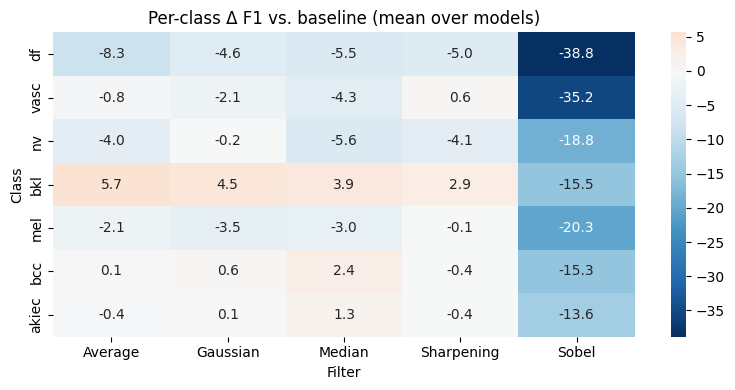

In [16]:
# which classes are most affected by filtering? mean |Δ per-class F1| across models
pc = pd.read_csv(f"{OUT}/reports/per_class.csv")
pc_base = pc[pc["Filter"] == "No Filter"].set_index(["Model", "Class"])["F1"]
pc_f = pc[pc["Filter"] != "No Filter"].copy()
pc_f["Δ F1"] = pc_f.apply(lambda r: r["F1"] - pc_base.loc[(r["Model"], r["Class"])], axis=1)

class_sens = pc_f.pivot_table(index="Class", columns="Filter", values="Δ F1", aggfunc="mean").loc[:, FILTERS[1:]].round(2)
class_sens["mean |Δ|"] = class_sens.abs().mean(1).round(2)
class_sens = class_sens.sort_values("mean |Δ|", ascending=False)
print("Per-class Δ F1 vs. baseline, averaged over the three models (pp)\n")
print(class_sens.to_string())
class_sens.to_csv(f"{OUT}/class_sensitivity.csv")

plt.figure(figsize=(8, 4))
sns.heatmap(class_sens.drop(columns="mean |Δ|"), annot=True, fmt=".1f", cmap="RdBu_r", center=0)
plt.title("Per-class Δ F1 vs. baseline (mean over models)"); plt.tight_layout()
plt.savefig(f"{OUT}/figures/class_sensitivity_heatmap.png", dpi=150); plt.show()

In [17]:
# one-paragraph summary to seed the written answers
lines = []
for m in BEST_MODELS:
    d = delta[delta["Model"] == m].set_index("Filter")["Δ Macro-F1"]
    lines.append(f"{m}: baseline Macro-F1 {base.loc[m, 'Macro-F1']:.2f}. "
                 f"Best filter {d.idxmax()} ({d.max():+.2f} pp), worst {d.idxmin()} ({d.min():+.2f} pp).")
mean_d = delta.groupby("Filter")["Δ Macro-F1"].mean().loc[FILTERS[1:]]
sign_consistent = delta.groupby("Filter")["Δ Macro-F1"].apply(lambda s: (np.sign(s) == np.sign(s.iloc[0])).all())
lines.append(f"Largest mean change: {mean_d.abs().idxmax()} ({mean_d[mean_d.abs().idxmax()]:+.2f} pp Macro-F1).")
lines.append("Direction consistent across all three models: " +
             ", ".join(f"{f} {'yes' if v else 'no'}" for f, v in sign_consistent.items()))
lines.append(f"Classes most sensitive to filtering: {', '.join(class_sens.index[:3])}.")
summary = "\n".join(lines)
print(summary)
open(f"{OUT}/summary.txt", "w").write(summary)
print("\nAll artefacts under", OUT)

ResNet50: baseline Macro-F1 76.41. Best filter Gaussian (+1.49 pp), worst Sobel (-21.95 pp).
DenseNet121: baseline Macro-F1 75.89. Best filter Sharpening (-1.02 pp), worst Sobel (-21.70 pp).
ResNet101: baseline Macro-F1 76.29. Best filter Median (+1.32 pp), worst Sobel (-23.88 pp).
Largest mean change: Sobel (-22.51 pp Macro-F1).
Direction consistent across all three models: Average no, Gaussian no, Median no, Sharpening yes, Sobel yes
Classes most sensitive to filtering: df, vasc, nv.

All artefacts under /kaggle/working/lab02
